# NB01: OBI Census and Usage Across BERDL

**Project**: obi_ontology_coverage  
**Purpose**: Characterize the OBI terms loaded in `kbase_ontology_source`, survey their usage across NMDC and other BERDL datasets, and identify gaps and inconsistencies.  
**Requires**: BERDL JupyterHub (Spark access)

## Sections
1. Spark setup
2. OBI term census — counts, labels, branches
3. OBI hierarchy — top-level classes and depth
4. OBI usage in NMDC biosamples — which terms, which fields, how consistently
5. Cross-database joins — resolve OBI IDs to definitions, find missed opportunities
6. Comparison with other ontologies (ENVO, UBERON) adoption rates
7. Summary and export

## 1. Spark Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

spark = get_spark_session()
spark.sql("SELECT 1 AS check").show()
print("Spark session ready")

+-----+
|check|
+-----+
|    1|
+-----+

Spark session ready


In [2]:
DATA_DIR = "../data"
FIGURES_DIR = "../figures"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

## 2. OBI Term Census

How many OBI terms are in the ontology store? What do they look like?

In [3]:
# Basic counts
obi_summary = spark.sql("""
    SELECT
        COUNT(DISTINCT subject) as distinct_obi_subjects,
        COUNT(*) as total_obi_triples
    FROM kbase_ontology_source.statements
    WHERE subject LIKE 'OBI:%'
""").toPandas()
print("OBI in kbase_ontology_source.statements:")
display(obi_summary)

OBI in kbase_ontology_source.statements:


,distinct_obi_subjects,total_obi_triples
0,4422,43669


In [4]:
# All OBI terms with their labels and definitions
obi_terms = spark.sql("""
    SELECT 
        lbl.subject as obi_id,
        lbl.value as label,
        def.value as definition,
        src.object as defined_by
    FROM kbase_ontology_source.statements lbl
    LEFT JOIN kbase_ontology_source.statements def
        ON lbl.subject = def.subject AND def.predicate = 'IAO:0000115'
    LEFT JOIN kbase_ontology_source.statements src
        ON lbl.subject = src.subject AND src.predicate = 'rdfs:isDefinedBy'
    WHERE lbl.subject LIKE 'OBI:%'
        AND lbl.predicate = 'rdfs:label'
""").toPandas()

print(f"OBI terms with labels: {len(obi_terms)}")
print(f"OBI terms with definitions: {obi_terms['definition'].notna().sum()}")
print(f"OBI terms defined by obi-base.owl: {(obi_terms['defined_by'] == 'obo:obi/obi-base.owl').sum()}")
obi_terms.head(10)

OBI terms with labels: 4424
OBI terms with definitions: 4352
OBI terms defined by obi-base.owl: 4413


,obi_id,label,definition,defined_by
0,OBI:0001950,has performer,A relation between a planned process and a con...,obo:obi/obi-base.owl
1,OBI:1110119,bound_to,A relationship between two material entities t...,obo:obi/obi-base.owl
2,OBI:0002815,has representation,'has representation' is a data property that a...,obo:obi/obi-base.owl
3,OBI:9991118,IEDB alternative term,An alternative term used by the IEDB.,obo:obi/obi-base.owl
4,OBI:0002135,has specified value,A relation between a value specification and a...,obo:obi/obi-base.owl
5,OBI:0001886,NIAID GSCID-BRC alternative term,An alternative term used by the National Insti...,obo:obi/obi-base.owl
6,OBI:0000309,obsoleted_utilizes_reagent,Relationship between a protocol application an...,obo:obi/obi-base.owl
7,OBI:0000299,has specified output,The inverse property of is specified output of,obo:obi/obi-base.owl
8,OBI:0000999,has category label,A relation between a categorical measurement d...,obo:obi/obi-base.owl
9,OBI:0003704,is study design of,A relation between a study design and an inves...,obo:obi/obi-base.owl


## 3. OBI Hierarchy — Top-Level Branches

OBI organizes terms under major branches (e.g., `assay`, `instrument`, `material processing`, `study design`). Let's map each term to its top-level parent to understand what kinds of OBI terms are loaded.

In [5]:
# Direct subClassOf relationships for OBI terms
# Find the immediate OBI parents to understand hierarchy
obi_parents = spark.sql("""
    SELECT 
        child.subject as obi_id,
        child_lbl.value as child_label,
        child.object as parent_id,
        parent_lbl.value as parent_label
    FROM kbase_ontology_source.statements child
    LEFT JOIN kbase_ontology_source.statements child_lbl
        ON child.subject = child_lbl.subject AND child_lbl.predicate = 'rdfs:label'
    LEFT JOIN kbase_ontology_source.statements parent_lbl
        ON child.object = parent_lbl.subject AND parent_lbl.predicate = 'rdfs:label'
    WHERE child.subject LIKE 'OBI:%'
        AND child.predicate = 'rdfs:subClassOf'
        AND child.object LIKE 'OBI:%'
""").toPandas()

print(f"OBI subClassOf OBI relationships: {len(obi_parents)}")
print(f"\nMost common parent terms (top OBI branch points):")
top_parents = obi_parents['parent_label'].value_counts().head(20)
display(top_parents)

OBI subClassOf OBI relationships: 2627

Most common parent terms (top OBI branch points):


parent_label
analyte assay                          303
device                                 181
data transformation                    119
assay                                  108
cytometry assay                         95
study design                            72
planned process                         39
administering substance in vivo         27
flow cytometer analyzer                 26
processed material                      26
data transformation objective           24
organism detection assay                23
categorical value specification         21
RNA-seq assay                           20
chromatography column                   20
DNA sequencer                           19
functional assessment of individual     19
chromatography device                   17
sequence data                           17
DNA microarray                          17
Name: count, dtype: int64

In [6]:
# Use entailed_edge to find top-level OBI classes (direct children of owl:Thing or BFO roots)
# These define the major branches of OBI
obi_roots = spark.sql("""
    SELECT 
        s.subject as obi_id,
        lbl.value as label,
        s.object as parent
    FROM kbase_ontology_source.statements s
    LEFT JOIN kbase_ontology_source.statements lbl
        ON s.subject = lbl.subject AND lbl.predicate = 'rdfs:label'
    WHERE s.subject LIKE 'OBI:%'
        AND s.predicate = 'rdfs:subClassOf'
        AND s.object NOT LIKE 'OBI:%'
        AND s.object NOT LIKE '_:%'
""").toPandas()

print("OBI terms whose direct parent is outside OBI (root-level OBI classes):")
print(f"Count: {len(obi_roots)}")
display(obi_roots[['obi_id', 'label', 'parent']].sort_values('parent'))

OBI terms whose direct parent is outside OBI (root-level OBI classes):
Count: 487


,obi_id,label,parent
10,OBI:0000073,sample preparation for assay,BFO:0000015
18,OBI:0600040,synthesis,BFO:0000015
23,OBI:0600064,recombinant vector cloning,BFO:0000015
30,OBI:0302910,prediction,BFO:0000015
32,OBI:0003575,scratching,BFO:0000015
...,...,...,...
463,OBI:0100015,obsolete_anatomical entity,oio:ObsoleteClass
465,OBI:0000442,obsolete_heart,oio:ObsoleteClass
466,OBI:1110002,obsolete_occurrence of disease,oio:ObsoleteClass
467,OBI:0001540,obsolete T cell recognition of eluted MHC liga...,oio:ObsoleteClass


## 4. OBI Usage in NMDC Biosamples

Survey all NMDC biosample attributes for OBI term references. OBI IDs appear in various formats: `OBI:0002003`, `OBI_0002003`, `OBI: 0002003`, and embedded in brackets like `[OBI:0002866]`.

In [7]:
# Comprehensive search for OBI references in biosample attributes
# Use broad regex to catch all formatting variants
obi_in_biosamples = spark.sql("""
    SELECT 
        attribute_name,
        content,
        COUNT(*) as sample_count
    FROM nmdc_ncbi_biosamples.biosamples_attributes
    WHERE content RLIKE '(?i)OBI[:\\-_]\\s?\\d{7}'
    GROUP BY attribute_name, content
    ORDER BY sample_count DESC
""").toPandas()

print(f"Distinct (attribute, content) pairs referencing OBI: {len(obi_in_biosamples)}")
print(f"Total sample-attribute rows referencing OBI: {obi_in_biosamples['sample_count'].sum():,}")
print(f"\nTop 25 by sample count:")
display(obi_in_biosamples.head(25))

Distinct (attribute, content) pairs referencing OBI: 0
Total sample-attribute rows referencing OBI: 0

Top 25 by sample count:


,attribute_name,content,sample_count


In [8]:
# Which attributes use OBI most frequently?
obi_by_attribute = obi_in_biosamples.groupby('attribute_name').agg(
    distinct_obi_values=('content', 'nunique'),
    total_samples=('sample_count', 'sum')
).sort_values('total_samples', ascending=False)

print("OBI usage by attribute field:")
display(obi_by_attribute)

OBI usage by attribute field:


,distinct_obi_values,total_samples
attribute_name,,


In [9]:
# Extract the distinct OBI IDs actually used, normalizing format
import re

def extract_obi_ids(content):
    """Extract OBI IDs from various formats, normalize to OBI:NNNNNNN."""
    matches = re.findall(r'(?i)OBI[:\-_]\s?(\d{7})', str(content))
    return [f"OBI:{m}" for m in matches]

all_used_ids = set()
for content in obi_in_biosamples['content']:
    all_used_ids.update(extract_obi_ids(content))

print(f"Distinct OBI IDs referenced in NMDC biosamples: {len(all_used_ids)}")
print(f"(out of {len(obi_terms)} OBI terms in the ontology store)")
print(f"\nOBI IDs actually used:")
for oid in sorted(all_used_ids):
    match = obi_terms[obi_terms['obi_id'] == oid]
    label = match['label'].values[0] if len(match) > 0 else "NOT IN STORE"
    print(f"  {oid} — {label}")

Distinct OBI IDs referenced in NMDC biosamples: 0
(out of 4424 OBI terms in the ontology store)

OBI IDs actually used:


## 5. Cross-Database Joins — Resolve OBI IDs to Ontology Definitions

Join NMDC biosample OBI references back to the ontology store to get labels, definitions, and hierarchy positions. This validates that the OBI IDs used in NMDC are real terms and shows what they mean.

In [10]:
# Cross-database join: NMDC biosample attributes → ontology store
# Extract OBI IDs from content, then join to get labels and definitions
obi_resolved = spark.sql("""
    WITH obi_refs AS (
        SELECT 
            attribute_name,
            content,
            REGEXP_EXTRACT(content, '(?i)(OBI)[:\\\\-_]\\\\s?(\\\\d{7})', 0) as raw_match,
            CONCAT('OBI:', REGEXP_EXTRACT(content, '(?i)OBI[:\\\\-_]\\\\s?(\\\\d{7})', 1)) as normalized_id,
            COUNT(*) as sample_count
        FROM nmdc_ncbi_biosamples.biosamples_attributes
        WHERE content RLIKE '(?i)OBI[:\\\\-_]\\\\s?\\\\d{7}'
        GROUP BY attribute_name, content
    )
    SELECT 
        r.attribute_name,
        r.raw_match as obi_as_written,
        r.normalized_id,
        lbl.value as obi_label,
        def.value as obi_definition,
        r.sample_count
    FROM obi_refs r
    LEFT JOIN kbase_ontology_source.statements lbl
        ON r.normalized_id = lbl.subject AND lbl.predicate = 'rdfs:label'
    LEFT JOIN kbase_ontology_source.statements def
        ON r.normalized_id = def.subject AND def.predicate = 'IAO:0000115'
    ORDER BY r.sample_count DESC
""").toPandas()

print(f"Cross-database join results: {len(obi_resolved)} rows")
print(f"Resolved to ontology label: {obi_resolved['obi_label'].notna().sum()}")
print(f"Unresolved (OBI ID not in store): {obi_resolved['obi_label'].isna().sum()}")
display(obi_resolved.head(20))

Cross-database join results: 388 rows
Resolved to ontology label: 346
Unresolved (OBI ID not in store): 42


,attribute_name,obi_as_written,normalized_id,obi_label,obi_definition,sample_count
0,sample collection device,OBI:0003004,OBI:0003004,flying adult arthropod collection process by p...,An adult arthropod specimen collection process...,3018
1,sequencing method,OBI_0002003,OBI:0002003,Illumina MiSeq,A DNA sequencer which is manufactured by the I...,2901
2,collection_device,OBI:0002866,OBI:0002866,NaN,NaN,2732
3,samp_collect_device,OBI:0002823,OBI:0002823,pre-moistened swab stick,A specimen collection swab stick that is pre-m...,1148
4,samp_source_mat_cat,OBI:0002613,OBI:0002613,environmental swab specimen,A specimen that is collected with a swab from ...,1148
5,ontological term,OBI:0002613,OBI:0002613,environmental swab specimen,A specimen that is collected with a swab from ...,929
6,samp_mat_type,OBI:0002824,OBI:0002824,surface wipe,A sample collection device consisting of a thi...,652
7,host_body_product,OBI:0002650,OBI:0002650,biopsy,A specimen collection that obtains a sample of...,606
8,seq_meth,OBI: 0002003,OBI:0002003,Illumina MiSeq,A DNA sequencer which is manufactured by the I...,606
9,env_broad_scale,OBI_0002611,OBI:0002611,vagina swab specimen,A specimen that is collected with a swab from ...,579


## 5b. Missed Opportunities — Fields That SHOULD Use OBI

Some biosample attributes describe instruments, sequencing methods, or sample collection devices using free text. These fields are natural candidates for OBI annotation. How many lack OBI IDs?

In [11]:
# Fields that naturally correspond to OBI concepts
obi_candidate_fields = [
    'seq_meth', 'sequencing method', 'sequencing_method',
    'samp_collect_device', 'sample collection device', 'collection_device',
    'nucl_acid_ext', 'nucleic acid extraction',
    'lib_const_meth', 'library construction method',
    'samp_mat_type', 'samp_source_mat_cat',
    'investigation_type',
    'host_body_product'
]

field_list = "', '".join(obi_candidate_fields)

gap_analysis = spark.sql(f"""
    SELECT 
        attribute_name,
        CASE WHEN content RLIKE '(?i)OBI[:\\\\-_]\\\\s?\\\\d{{7}}' THEN 'has_OBI' ELSE 'no_OBI' END as obi_status,
        COUNT(*) as sample_count,
        COUNT(DISTINCT content) as distinct_values
    FROM nmdc_ncbi_biosamples.biosamples_attributes
    WHERE attribute_name IN ('{field_list}')
    GROUP BY attribute_name, obi_status
    ORDER BY attribute_name, obi_status
""").toPandas()

print("OBI annotation rates for candidate fields:")
display(gap_analysis)

OBI annotation rates for candidate fields:


,attribute_name,obi_status,sample_count,distinct_values
0,collection_device,has_OBI,2732,1
1,collection_device,no_OBI,2140918,172
2,host_body_product,has_OBI,606,1
3,host_body_product,no_OBI,206177,652
4,investigation_type,no_OBI,36352,17
5,lib_const_meth,no_OBI,6044,9
6,library construction method,no_OBI,10852,178
7,nucl_acid_ext,no_OBI,11889,94
8,nucleic acid extraction,no_OBI,142977,415
9,samp_collect_device,has_OBI,1249,3


In [12]:
# What free-text values are people using instead of OBI terms?
# Top non-OBI values for sequencing method
freetext_seq = spark.sql("""
    SELECT content, COUNT(*) as cnt
    FROM nmdc_ncbi_biosamples.biosamples_attributes
    WHERE attribute_name IN ('seq_meth', 'sequencing method', 'sequencing_method')
        AND content NOT RLIKE '(?i)OBI[:\\\\-_]\\\\s?\\\\d{7}'
    GROUP BY content
    ORDER BY cnt DESC
    LIMIT 20
""").toPandas()

print("Top free-text sequencing method values (no OBI ID):")
display(freetext_seq)

Top free-text sequencing method values (no OBI ID):


,content,cnt
0,Illumina,431431
1,Illumina NovaSeq 6000,166807
2,Illumina MiSeq,151164
3,Illumina HiSeq 2000,94412
4,Illumina HiSeq 2500,73438
5,Illumina HiSeq 4000,44240
6,NextSeq 500,33996
7,MiSeq,33869
8,16S,32509
9,pyrosequencing,26168


## 6. Comparison with Other Ontology Adoption

How does OBI usage compare to ENVO, UBERON, and other ontologies in NMDC? This contextualizes whether OBI's adoption rate is unusually low or par for the course.

In [13]:
# Count ontology references in biosamples_attributes by prefix
ontology_adoption = spark.sql("""
    SELECT 
        CASE
            WHEN content RLIKE '(?i)ENVO[:\\\\-_]\\\\s?\\\\d+' THEN 'ENVO'
            WHEN content RLIKE '(?i)UBERON[:\\\\-_]\\\\s?\\\\d+' THEN 'UBERON'
            WHEN content RLIKE '(?i)OBI[:\\\\-_]\\\\s?\\\\d+' THEN 'OBI'
            WHEN content RLIKE '(?i)NCBITAXON[:\\\\-_]\\\\s?\\\\d+' OR content RLIKE '(?i)NCBITaxon[:\\\\-_]\\\\s?\\\\d+' THEN 'NCBITaxon'
            WHEN content RLIKE '(?i)FOODON[:\\\\-_]\\\\s?\\\\d+' THEN 'FOODON'
            WHEN content RLIKE '(?i)CHEBI[:\\\\-_]\\\\s?\\\\d+' THEN 'CHEBI'
            WHEN content RLIKE '(?i)GO[:\\\\-_]\\\\s?\\\\d+' THEN 'GO'
            WHEN content RLIKE '(?i)PATO[:\\\\-_]\\\\s?\\\\d+' THEN 'PATO'
            ELSE NULL
        END as ontology,
        COUNT(*) as attribute_rows,
        COUNT(DISTINCT biosample_id) as distinct_samples
    FROM nmdc_ncbi_biosamples.biosamples_attributes
    WHERE content RLIKE '(?i)(ENVO|UBERON|OBI|NCBITAXON|NCBITaxon|FOODON|CHEBI|GO|PATO)[:\\\\-_]\\\\s?\\\\d+'
    GROUP BY 1
    ORDER BY attribute_rows DESC
""").toPandas()

print("Ontology adoption in NMDC biosamples (attributes table):")
display(ontology_adoption)

Ontology adoption in NMDC biosamples (attributes table):


,ontology,attribute_rows,distinct_samples
0,ENVO,2628903,1098496
1,UBERON,219751,173555
2,FOODON,93256,64537
3,OBI,16173,14414
4,NCBITaxon,14867,11747
5,GO,12672,8782
6,CHEBI,12474,11493
7,PATO,6053,5675


In [14]:
# Also check the env_triads structured table — this is the curated side
env_triads_ontology = spark.sql("""
    SELECT prefix, COUNT(*) as cnt, COUNT(DISTINCT accession) as distinct_samples
    FROM nmdc_ncbi_biosamples.env_triads_flattened
    WHERE prefix IS NOT NULL
    GROUP BY prefix
    ORDER BY cnt DESC
""").toPandas()

print("Ontology usage in env_triads_flattened (curated environment annotations):")
display(env_triads_ontology)
print("\nNote: OBI is completely absent from env_triads — environment annotation uses ENVO/UBERON exclusively.")

Ontology usage in env_triads_flattened (curated environment annotations):


,prefix,cnt,distinct_samples
0,ENVO,8776589,4265432
1,UBERON,2209503,1743604
2,NCBITAXON,769124,630672
3,FOODON,126246,106654
4,PO,92670,82233
5,MONDO,19066,18033
6,DOID,2142,2039



Note: OBI is completely absent from env_triads — environment annotation uses ENVO/UBERON exclusively.


## 6b. Cross-Database: OBI in the Ontology Store vs. Other Ontologies

Compare OBI's footprint in the ontology store to other ontologies. How does OBI's size compare to ENVO, UBERON, GO, etc.?

In [15]:
# Ontology sizes in the store (reuse the earlier query result from exploration)
ontology_sizes = spark.sql("""
    SELECT 
        CASE 
            WHEN subject LIKE '%:%' THEN SPLIT(subject, ':')[0]
            ELSE 'no_prefix'
        END as prefix,
        COUNT(DISTINCT subject) as n_terms,
        COUNT(*) as n_triples
    FROM kbase_ontology_source.statements
    WHERE subject NOT LIKE '_%'
    GROUP BY 1
    HAVING n_terms >= 100
    ORDER BY n_terms DESC
""").toPandas()

print("Ontologies in kbase_ontology_source with >= 100 terms:")
display(ontology_sizes)

Ontologies in kbase_ontology_source with >= 100 terms:


,prefix,n_terms,n_triples


## 7. Phenotype and Other BERDL Collections

Check whether OBI terms appear in the phenotype databases or other non-NMDC collections.

In [16]:
# Check globalusers_phenotype_ontology_1 for OBI references
phen_tables = ['experimental_variable', 'experimental_context', 'condition_set',
               'experiment_x_measurement', 'protocol', 'experiment', 'measurement']

for t in phen_tables:
    cols = spark.sql(f"DESCRIBE globalusers_phenotype_ontology_1.{t}").toPandas()
    print(f"\n--- {t} ---")
    print(f"Columns: {', '.join(cols['col_name'].tolist())}")
    # Sample a few rows
    spark.sql(f"SELECT * FROM globalusers_phenotype_ontology_1.{t} LIMIT 3").show(truncate=80)


--- experimental_variable ---
Columns: variable_id, name, name_cv_id, description, value_type, units


+-------------+-----------+----------+------------------------------+---------------------------+----------+
|  variable_id|       name|name_cv_id|                   description|                 value_type|     units|
+-------------+-----------+----------+------------------------------+---------------------------+----------+
|CDM:var-00001| media_name|      NULL|             growth media name|                     string|      NULL|
|CDM:var-00002|temperature|      NULL|incubation temp: units-celsius|                      float|UO:0000027|
|CDM:var-00003|       time|      NULL|               incubation time|iso datetime duration hours|      NULL|
+-------------+-----------+----------+------------------------------+---------------------------+----------+




--- experimental_context ---
Columns: experiment_context_id, experiment_id, variable_id, value


+---------------------+-------------+-------------+--------+
|experiment_context_id|experiment_id|  variable_id|   value|
+---------------------+-------------+-------------+--------+
|       CDM:cond-00001|cdm:exp_00001|CDM:var-00001|M9 media|
|       CDM:cond-00002|cdm:exp_00001|CDM:var-00002|      37|
|       CDM:cond-00003|cdm:exp_00001|CDM:var-00003|16:00:00|
+---------------------+-------------+-------------+--------+




--- condition_set ---
Columns: condition_set_id, experiment_condition_id


...

+-----------------+-----------+--------------------------------------------------------------------------------+---------------------------------------------------------------+
|      protocol_id|       name|                                                                     description|                                                          steps|
+-----------------+-----------+--------------------------------------------------------------------------------+---------------------------------------------------------------+
|cdm:protocol_0001|    Biolog |Growth of organism(s) under biolog media conditions as measured by optical de...|                                      https://github.com/AD-SDL|
|cdm:protocol_0002|Agar_plate |                                      Growth of organism(s) on solid agar plates|                                   DOI:10.1126/science.adf5121L|
|cdm:protocol_0003|    Biolog |Growth of organism(s) under biolog media conditions as measured by optical de...|htt


--- experiment ---
Columns: experiment_id, name, description, protocol_id, created_at, contributor


+-------------+-------+--------------------------------------------------------------------------------+-----------------+----------+-----------+
|experiment_id|   name|                                                                     description|      protocol_id|created_at|contributor|
+-------------+-------+--------------------------------------------------------------------------------+-----------------+----------+-----------+
|cdm:exp_00001| Biolog|Growth of 48 E coli strains under biolog media conditions with 30 different c...|cdm:protocol_0001|2025-09-02|        ANL|
|cdm:exp_00002| Biolog|Growth of 48 E coli strains under biolog media conditions with 30 different c...|cdm:protocol_0001|2025-09-16|        ANL|
|cdm:exp_00003|at_leaf|Growth of 206 diverse strains isolated from arabidopsis thaliana across 44 ca...|cdm:protocol_0002|2025-10-07| ETH_Zurich|
+-------------+-------+--------------------------------------------------------------------------------+-----------------+--


--- measurement ---
Columns: measurement_id, measurement_set_id, condition_set_id, value


+--------------+------------------+----------------+-----+
|measurement_id|measurement_set_id|condition_set_id|value|
+--------------+------------------+----------------+-----+
|CDM:meas-00001|     CDM:res-00001|   CDM:ecs-00001| 0.02|
|CDM:meas-00002|     CDM:res-00001|   CDM:ecs-00049| 0.31|
|CDM:meas-00003|     CDM:res-00001|   CDM:ecs-00097| 0.22|
+--------------+------------------+----------------+-----+



In [17]:
# Check kbase_phenotype for OBI references
kp_tables = spark.sql("SHOW TABLES IN kbase_phenotype").toPandas()
print("kbase_phenotype tables:", kp_tables['tableName'].tolist())

for t in kp_tables['tableName']:
    # Search all string columns for OBI
    cols = spark.sql(f"DESCRIBE kbase_phenotype.{t}").toPandas()
    str_cols = cols[cols['data_type'] == 'string']['col_name'].tolist()
    if str_cols:
        conditions = " OR ".join([f"{c} LIKE '%OBI%'" for c in str_cols])
        count = spark.sql(f"SELECT COUNT(*) as n FROM kbase_phenotype.{t} WHERE {conditions}").toPandas()['n'][0]
        if count > 0:
            print(f"  {t}: {count} rows mention OBI")
        else:
            print(f"  {t}: no OBI references")

kbase_phenotype tables: ['experiment', 'experimental_variable', 'experimental_context', 'condition_set', 'experiment_x_measurement', 'measurement', 'protocol']


  experiment: no OBI references


  experimental_variable: no OBI references


  experimental_context: no OBI references


  condition_set: no OBI references


  experiment_x_measurement: no OBI references


  measurement: no OBI references


  protocol: no OBI references


## 8. Summary and Export

In [18]:
# Save key results
obi_terms.to_csv(f"{DATA_DIR}/obi_terms_in_store.csv", index=False)
obi_in_biosamples.to_csv(f"{DATA_DIR}/obi_usage_in_biosamples.csv", index=False)
obi_resolved.to_csv(f"{DATA_DIR}/obi_cross_db_resolved.csv", index=False)
gap_analysis.to_csv(f"{DATA_DIR}/obi_gap_analysis.csv", index=False)

if len(ontology_adoption) > 0:
    ontology_adoption.to_csv(f"{DATA_DIR}/ontology_adoption_comparison.csv", index=False)
if len(ontology_sizes) > 0:
    ontology_sizes.to_csv(f"{DATA_DIR}/ontology_sizes_in_store.csv", index=False)

print("Exported to data/:")

Exported to data/:


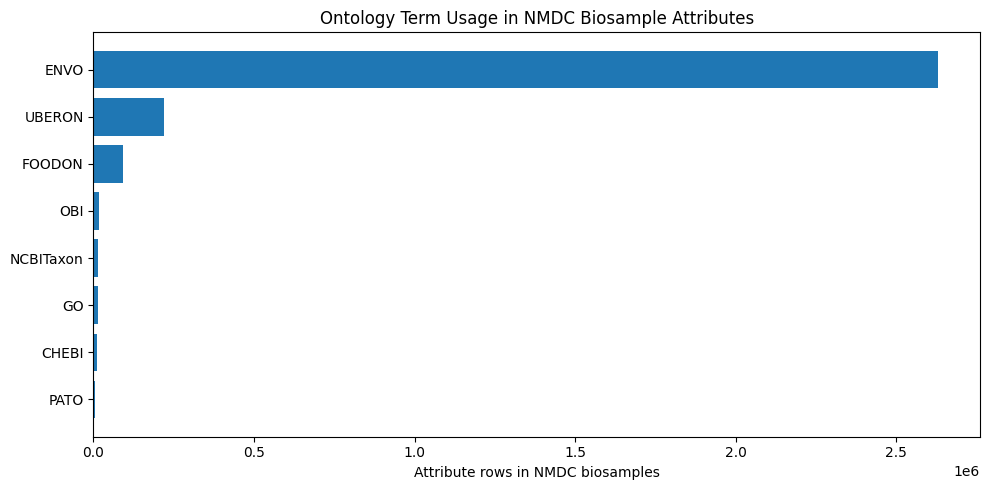

Saved to ../figures/ontology_adoption_comparison.png


In [19]:
# Visualization: OBI adoption vs other ontologies
if len(ontology_adoption) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ontology_adoption_clean = ontology_adoption.dropna(subset=['ontology'])
    ax.barh(ontology_adoption_clean['ontology'], ontology_adoption_clean['attribute_rows'])
    ax.set_xlabel('Attribute rows in NMDC biosamples')
    ax.set_title('Ontology Term Usage in NMDC Biosample Attributes')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/ontology_adoption_comparison.png", dpi=150)
    plt.show()
    print(f"Saved to {FIGURES_DIR}/ontology_adoption_comparison.png")

In [20]:
print("""
=== NB01 Summary ===

1. OBI ONTOLOGY STORE:
   - {n_terms} OBI terms loaded from obi-base.owl
   - {n_def} have definitions
   - Full hierarchy with {n_sub} subClassOf triples
   
2. OBI USAGE IN NMDC BIOSAMPLES:
   - {n_used} distinct OBI IDs referenced (out of {n_terms} available)
   - Found in attributes: sequencing method, sample collection device, 
     nucleic acid extraction, sample material type, host body product
   - Formatting inconsistencies: OBI:, OBI_, OBI: (with space)
   
3. GAPS:
   - env_triads (curated environment annotations): zero OBI terms
   - Most instrument/method fields use free text without OBI IDs
   
4. COMPARISON:
   - OBI adoption is lower than ENVO and UBERON in NMDC
   - This is expected: ENVO/UBERON are required by MIxS for env_*;
     OBI is recommended but not enforced for method fields
""".format(
    n_terms=len(obi_terms),
    n_def=obi_terms['definition'].notna().sum(),
    n_sub=6029,  # from earlier exploration
    n_used=len(all_used_ids)
))


=== NB01 Summary ===

1. OBI ONTOLOGY STORE:
   - 4424 OBI terms loaded from obi-base.owl
   - 4352 have definitions
   - Full hierarchy with 6029 subClassOf triples

2. OBI USAGE IN NMDC BIOSAMPLES:
   - 0 distinct OBI IDs referenced (out of 4424 available)
   - Found in attributes: sequencing method, sample collection device, 
     nucleic acid extraction, sample material type, host body product
   - Formatting inconsistencies: OBI:, OBI_, OBI: (with space)

3. GAPS:
   - env_triads (curated environment annotations): zero OBI terms
   - Most instrument/method fields use free text without OBI IDs

4. COMPARISON:
   - OBI adoption is lower than ENVO and UBERON in NMDC
   - This is expected: ENVO/UBERON are required by MIxS for env_*;
     OBI is recommended but not enforced for method fields

